In [ ]:
# CELL 1: Imports and Class Definition
%pip install statsmodels scikit-learn --quiet

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_error


[notice] A new release of pip is available: 24.2 -> 26.0
[notice] To update, run: C:\Users\yohan\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


In [5]:
# This ensures plots appear inside the notebook
%matplotlib inline 

class TrafficPrediction():
    def __init__(self):
        self.df = None
        self.training_data = None
        self.prediction = None

    def read_from_csv(self, filename, sample_period):
        print(f"Loading file: {filename}...")
        self.df = pd.read_csv(filename)
        
        # Parse time from unix to pandas format
        self.df['ds'] = pd.to_datetime(self.df['ds'], unit='s')   
        
        # Set index and Resample (Aggregation)
        self.df.set_index('ds', inplace=True)  
        self.df = self.df.resample(sample_period).sum(numeric_only=True).fillna(0) 
        
        # Convert from bytes to Mbps
        self.df['y'] /= pd.Timedelta(sample_period).total_seconds()
        self.df['y'] *= 8 
        self.df['y'] /= 2**20
        print(f"Data loaded. Shape: {self.df.shape}")
        
    def run_arima(self, order, training_split=.8):
        # Split data
        split_idx = int(training_split * len(self.df))
        self.training_data = self.df.iloc[:split_idx] 
        test_data = self.df.iloc[split_idx:]
        
        # Train Model
        print(f"Training ARIMA model with order {order}...")
        model = ARIMA(self.training_data, order=order)
        fitted_model = model.fit()
        
        # Predict
        self.prediction = fitted_model.predict(start=self.df.index.min(), end=self.df.index.max())

        # Enforce floor of 0 (Physics fix)
        self.prediction[self.prediction < 0] = 0
        
        # Calculate performance metrics on the test set
        test_predictions = self.prediction.loc[test_data.index]
        
        # Handle case where indices might not perfectly align due to resampling
        common_idx = test_data.index.intersection(test_predictions.index)
        mae = mean_absolute_error(test_data.loc[common_idx]['y'], test_predictions.loc[common_idx])
        rmse = np.sqrt(mean_squared_error(test_data.loc[common_idx]['y'], test_predictions.loc[common_idx]))
        
        return mae, rmse, fitted_model
            
    def plot(self, ax):
        # Plot Prediction
        ax.plot(self.prediction, label="ARIMA Prediction", linewidth=2) 
        # Plot Actual Data
        ax.plot(self.df, label="Actual Data", linestyle='dotted', alpha=0.7)
        # Plot Split Line
        ax.axvline(x=self.training_data.index.max(), color='red', linestyle='--', label='Training Split')
        ax.legend()
        ax.grid(True, alpha=0.3)

In [88]:
# CELL 2: Configuration
# Point this to the specific file you want to analyze
# Example: The backbone link between Switch 1 and Switch 2
TARGET_FILE = "captures/s1/eth3.csv" 

# Simulation Parameters
SAMPLE_PERIOD = "1s"      # 1 Second aggregation (Smoother)
TRAINING_SPLIT = 0.80     # 80% Training, 20% Testing
ARIMA_ORDER = (36, 1, 1)  # (p,d,q) - The tuning parameters

Loading file: captures/s1/eth3.csv...
Data loaded. Shape: (61, 1)

First 5 rows of processed data (Mbps):


,y
ds,
2026-02-01 23:04:22,0.523499
2026-02-01 23:04:23,0.232422
2026-02-01 23:04:24,0.129196
2026-02-01 23:04:25,1.482300
2026-02-01 23:04:26,0.233154



Data Statistics:


,y
count,61.000000
mean,0.604972
std,0.603652
min,0.047775
25%,0.129196
50%,0.279297
75%,0.978409
max,2.215912


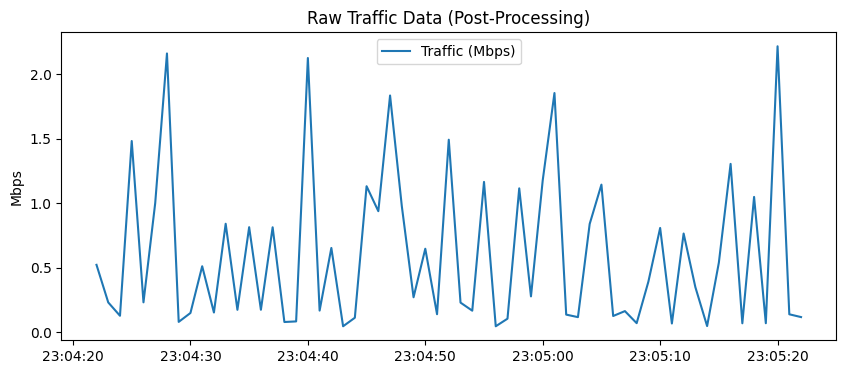

In [89]:
# CELL 3: Data Loading and Inspection
predictor = TrafficPrediction()

# Load the data
# Note: If this fails, check that the 'captures' folder is in the right place!
try:
    predictor.read_from_csv(TARGET_FILE, SAMPLE_PERIOD)
    
    # Show the first 5 rows (The Dataframe)
    print("\nFirst 5 rows of processed data (Mbps):")
    display(predictor.df.head())

    # Show basic statistics (Max, Min, Mean)
    print("\nData Statistics:")
    display(predictor.df.describe())

    # Quick plot to check for stationarity/burstiness
    plt.figure(figsize=(10, 4))
    plt.plot(predictor.df, label='Traffic (Mbps)')
    plt.title("Raw Traffic Data (Post-Processing)")
    plt.ylabel("Mbps")
    plt.legend()
    plt.show()

except FileNotFoundError:
    print(f"ERROR: Could not find file {TARGET_FILE}. Please check the path.")

In [90]:
# CELL 4: Run ARIMA
try:
    mae, rmse, model_details = predictor.run_arima(order=ARIMA_ORDER, training_split=TRAINING_SPLIT)
    
    print("-" * 30)
    print(f"RESULTS for {TARGET_FILE}")
    print("-" * 30)
    print(f"Mean Absolute Error (MAE): {mae:.4f} Mbps")
    print(f"Root Mean Squared Error (RMSE): {rmse:.4f} Mbps")
    print("-" * 30)
    
except Exception as e:
    print(f"An error occurred during training: {e}")

Training ARIMA model with order (36, 1, 1)...
------------------------------
RESULTS for captures/s1/eth3.csv
------------------------------
Mean Absolute Error (MAE): 0.4446 Mbps
Root Mean Squared Error (RMSE): 0.5532 Mbps
------------------------------


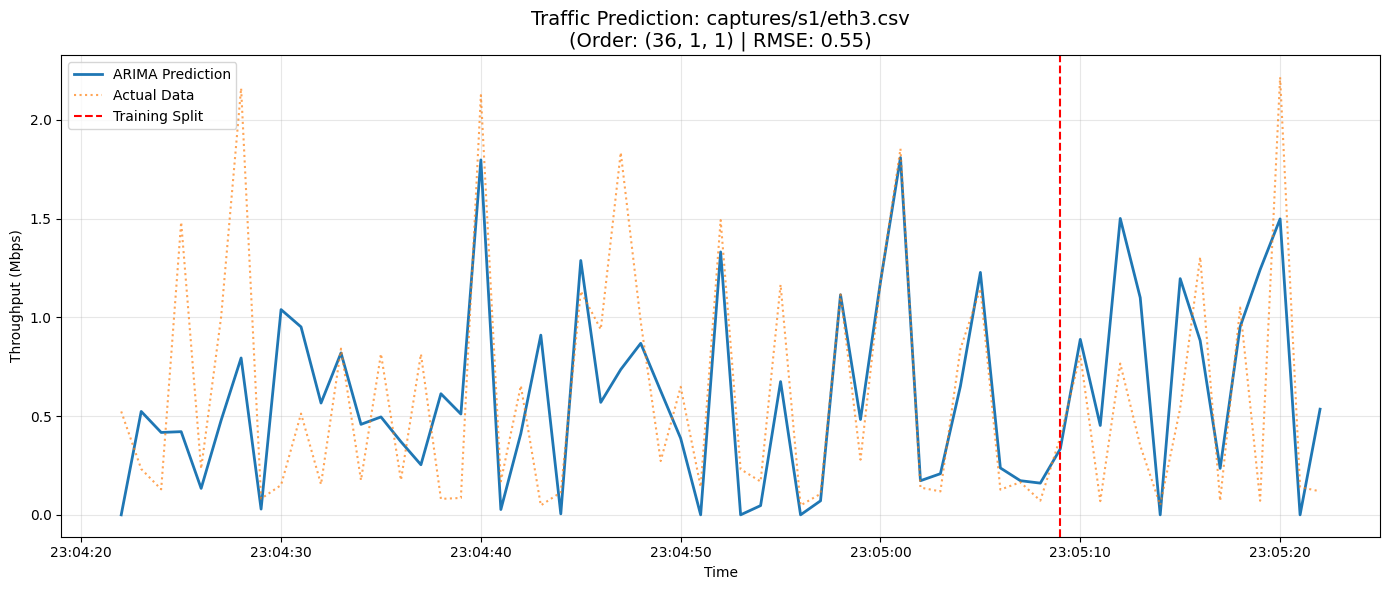

In [91]:
# CELL 5: Visualization
fig, ax = plt.subplots(figsize=(14, 6))

predictor.plot(ax)

ax.set_title(f"Traffic Prediction: {TARGET_FILE}\n(Order: {ARIMA_ORDER} | RMSE: {rmse:.2f})", fontsize=14)
ax.set_ylabel("Throughput (Mbps)")
ax.set_xlabel("Time")

plt.tight_layout()
plt.show()


Processing Switch: s1
Loading file: captures\s1\eth1.csv...
Data loaded. Shape: (61, 1)
Training ARIMA model with order (36, 1, 1)...
Loading file: captures\s1\eth2.csv...
Data loaded. Shape: (62, 1)
Training ARIMA model with order (36, 1, 1)...
Loading file: captures\s1\eth3.csv...
Data loaded. Shape: (61, 1)
Training ARIMA model with order (36, 1, 1)...


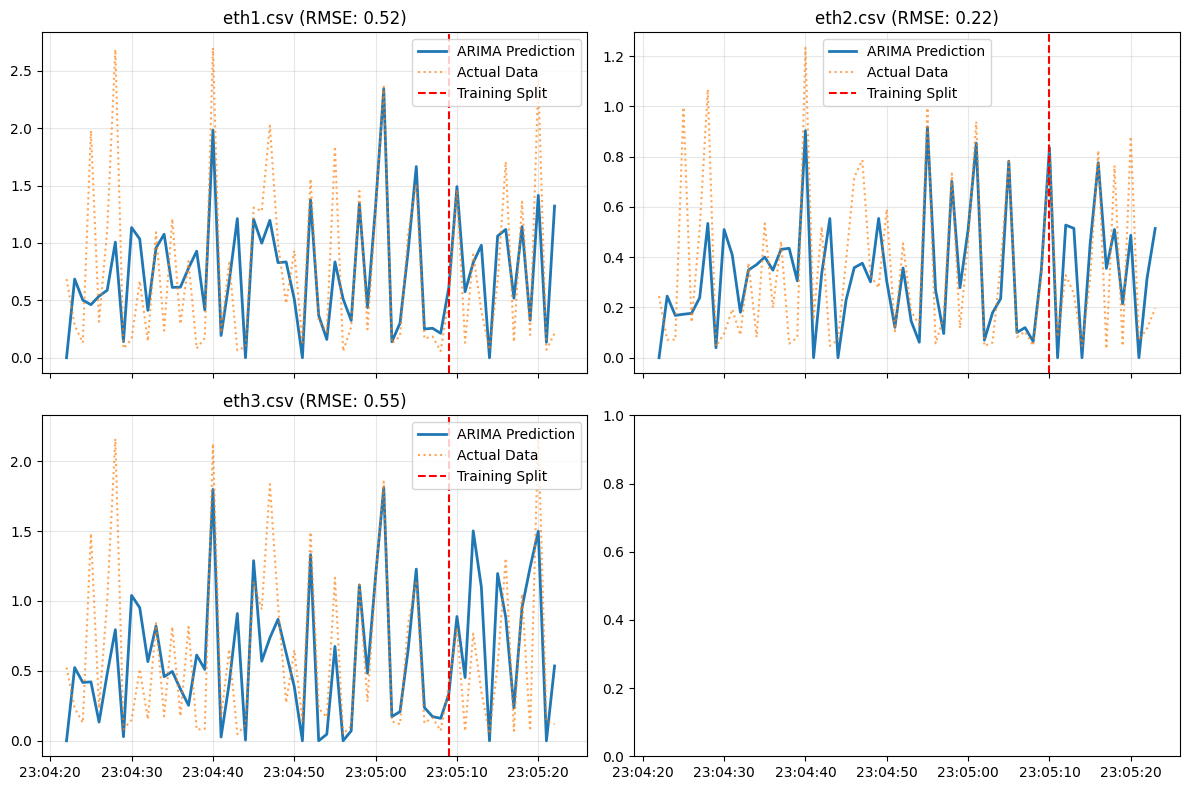


Processing Switch: s2
Loading file: captures\s2\eth1.csv...
Data loaded. Shape: (62, 1)
Training ARIMA model with order (36, 1, 1)...
Loading file: captures\s2\eth2.csv...
Data loaded. Shape: (62, 1)
Training ARIMA model with order (36, 1, 1)...
Loading file: captures\s2\eth3.csv...
Data loaded. Shape: (62, 1)
Training ARIMA model with order (36, 1, 1)...


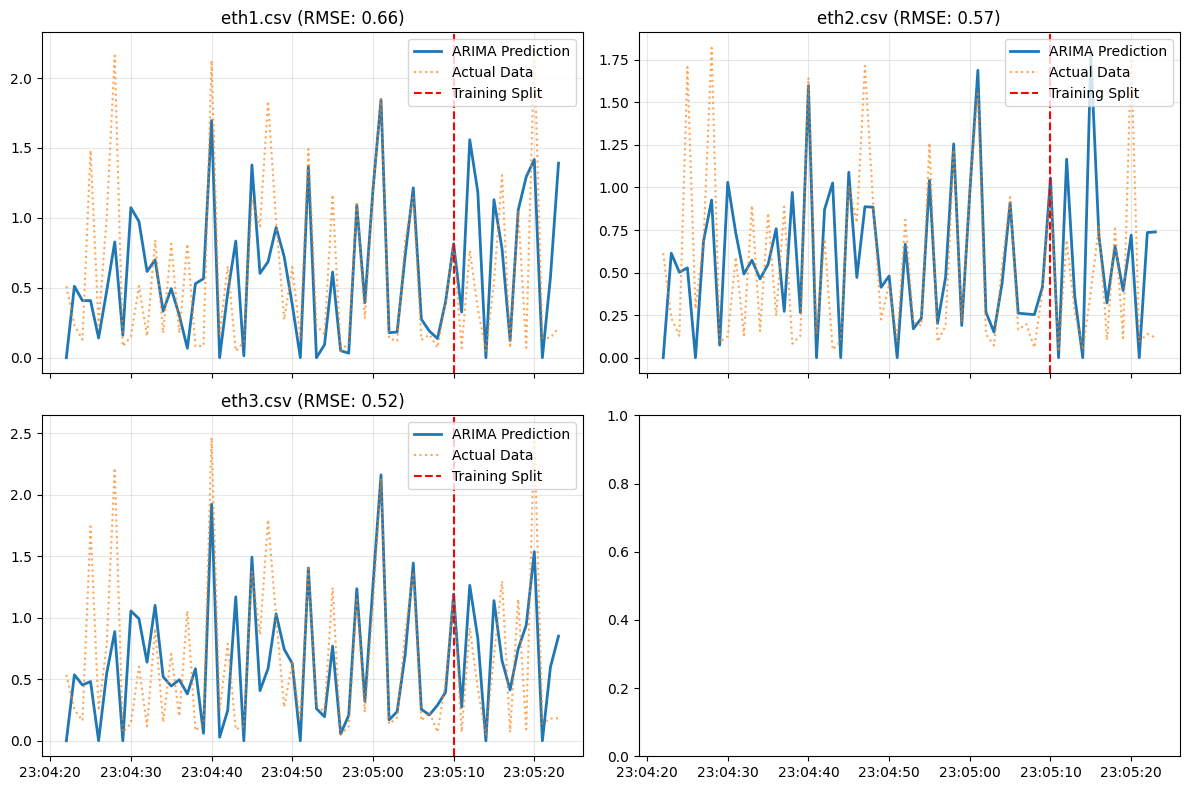

In [92]:
# CELL 6: Optional - Run Batch Analysis on All Files
ROOT_DIR = "captures"

if os.path.exists(ROOT_DIR):
    for switch in sorted(os.listdir(ROOT_DIR)):
        switch_path = os.path.join(ROOT_DIR, switch)
        if not os.path.isdir(switch_path): continue
            
        csv_files = [f for f in os.listdir(switch_path) if f.endswith('.csv')]
        
        print(f"\nProcessing Switch: {switch}")
        
        # Setup grid for plotting
        num_plots = len(csv_files)
        if num_plots == 0: continue
        
        cols = math.ceil(math.sqrt(num_plots))
        rows = math.ceil(num_plots / cols)
        
        fig, axs = plt.subplots(rows, cols, figsize=(12, 4*rows), sharex=True)
        axs = np.array(axs).flatten() # Handle single/multi plot consistency
        
        for i, file in enumerate(csv_files):
            filepath = os.path.join(switch_path, file)
            ax = axs[i]
            
            p = TrafficPrediction()
            p.read_from_csv(filepath, SAMPLE_PERIOD)
            mae, rmse, _ = p.run_arima(ARIMA_ORDER, TRAINING_SPLIT)
            
            p.plot(ax)
            ax.set_title(f"{file} (RMSE: {rmse:.2f})")
            
        plt.tight_layout()
        plt.show()
else:
    print("Captures folder not found.")

In [93]:
# check for stationary of time series data
from statsmodels.tsa.stattools import adfuller
def check_stationarity(ts):
    result = adfuller(ts)
    print('ADF Statistic:', result[0])
    print('p-value:', result[1])
    for key, value in result[4].items():
        print('Critical Value (%s): %.3f' % (key, value))
    if result[1] <= 0.05:
        print("The time series is stationary.")
    else:
        print("The time series is non-stationary.")
check_stationarity(predictor.df['y'])


ADF Statistic: -9.421227778251362
p-value: 5.496335589015264e-16
Critical Value (1%): -3.544
Critical Value (5%): -2.911
Critical Value (10%): -2.593
The time series is stationary.


In [82]:
# CELL 1: Import Statistical Tools
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

# Define the target file (Backbone link is usually the best one to analyze)
TARGET_FILE = "captures/s2/eth3.csv"

Loading file: captures/s2/eth3.csv...
Data loaded. Shape: (62, 1)


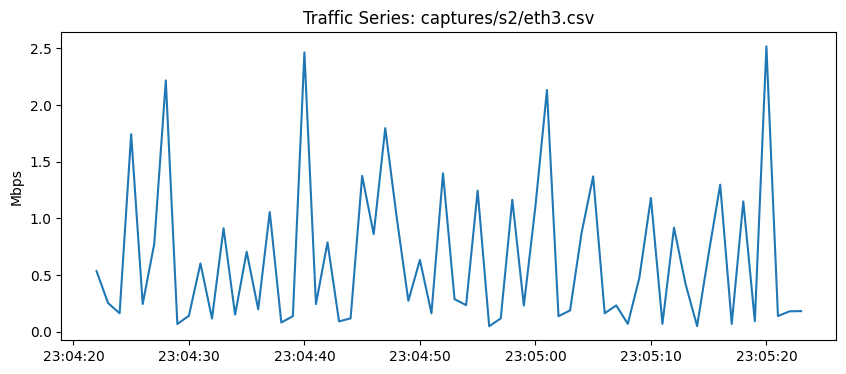

In [83]:
# CELL 2: Load Data
predictor = TrafficPrediction()

try:
    # Load and resample to 1 Second
    predictor.read_from_csv(TARGET_FILE, sample_period="1s")
    
    # Extract the series we want to test
    time_series = predictor.df['y']
    
    # Plot it just to see it
    plt.figure(figsize=(10, 4))
    plt.plot(time_series)
    plt.title(f"Traffic Series: {TARGET_FILE}")
    plt.ylabel("Mbps")
    plt.show()

except FileNotFoundError:
    print("File not found. Please check the path.")

In [84]:
# CELL 3: Augmented Dickey-Fuller Test
print("Results of Augmented Dickey-Fuller Test:")
print("-" * 40)

dftest = adfuller(time_series.dropna(), autolag='AIC')

dfoutput = pd.Series(dftest[0:4], index=['Test Statistic','p-value','#Lags Used','Number of Observations Used'])
for key, value in dftest[4].items():
    dfoutput['Critical Value (%s)'%key] = value

print(dfoutput)

print("-" * 40)
if dfoutput['p-value'] < 0.05:
    print("CONCLUSION: The data is STATIONARY (d=0 might be okay).")
else:
    print("CONCLUSION: The data is NON-STATIONARY (You need d=1 or more).")

Results of Augmented Dickey-Fuller Test:
----------------------------------------
Test Statistic                -1.002686e+01
p-value                        1.623418e-17
#Lags Used                     0.000000e+00
Number of Observations Used    6.100000e+01
Critical Value (1%)           -3.542413e+00
Critical Value (5%)           -2.910236e+00
Critical Value (10%)          -2.592745e+00
dtype: float64
----------------------------------------
CONCLUSION: The data is STATIONARY (d=0 might be okay).


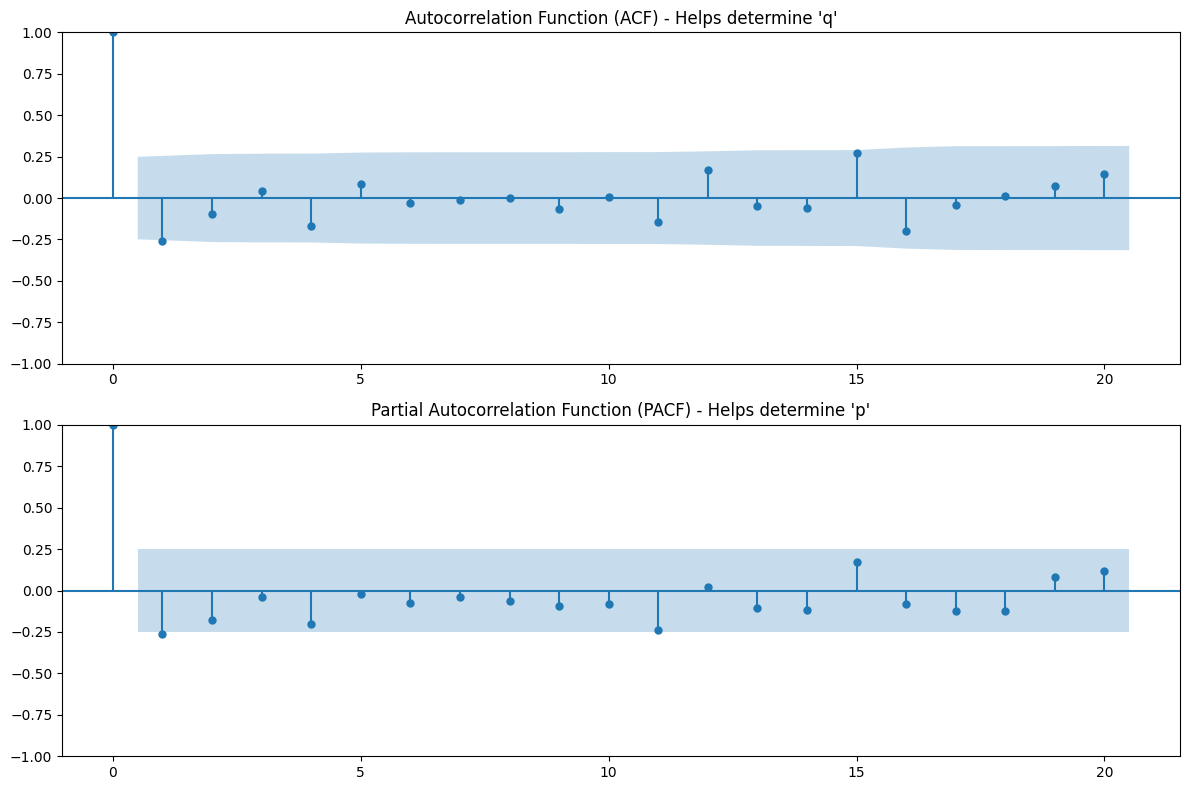

In [85]:
# CELL 4: Plot ACF and PACF
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

# Plot ACF (Limit lags to 20 because your dataset is short)
plot_acf(time_series, ax=ax1, lags=20)
ax1.set_title("Autocorrelation Function (ACF) - Helps determine 'q'")

# Plot PACF
# Note: method='ywm' is more stable for short datasets
plot_pacf(time_series, ax=ax2, lags=20, method='ywm') 
ax2.set_title("Partial Autocorrelation Function (PACF) - Helps determine 'p'")

plt.tight_layout()
plt.show()

In [86]:
# !pip install pmdarima  <-- Run this in a separate cell first

import pmdarima as pm

print("Running AutoARIMA...")

# auto_arima will automatically find the best parameters
model = pm.auto_arima(predictor.df['y'], 
                      start_p=1, start_q=0,
                      max_p=40, max_q=3,
                      m=1,              # Frequency of series
                      d=None,           # Let model figure out 'd'
                      seasonal=False,   # No seasonal component (SARIMA)
                      stepwise=True,
                      trace=True)

print(model.summary())

Running AutoARIMA...
Performing stepwise search to minimize aic
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=160.198, Time=0.03 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=167.330, Time=0.01 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=163.782, Time=0.02 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=153.351, Time=0.01 sec
 ARIMA(3,0,0)(0,0,0)[0]             : AIC=145.677, Time=0.05 sec
 ARIMA(4,0,0)(0,0,0)[0]             : AIC=146.636, Time=0.03 sec
 ARIMA(3,0,1)(0,0,0)[0]             : AIC=inf, Time=0.16 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=inf, Time=0.09 sec
 ARIMA(4,0,1)(0,0,0)[0]             : AIC=inf, Time=0.20 sec
 ARIMA(3,0,0)(0,0,0)[0] intercept   : AIC=125.308, Time=0.07 sec
 ARIMA(2,0,0)(0,0,0)[0] intercept   : AIC=123.478, Time=0.02 sec
 ARIMA(1,0,0)(0,0,0)[0] intercept   : AIC=123.617, Time=0.02 sec
 ARIMA(2,0,1)(0,0,0)[0] intercept   : AIC=inf, Time=0.11 sec
 ARIMA(1,0,1)(0,0,0)[0] intercept   : AIC=inf, Time=0.10 sec
 ARIMA(3,0,1)(0,0,0)[0] intercept   : AIC=inf,

In [87]:
# CELL: Hyperparameter Tuning (Grid Search)
import itertools
import warnings
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error

# 1. Define the range of parameters to test
# p: Look back 1, 2, 4, 8, or 12 seconds
p_values = [1, 2, 4, 8, 12,16,20,24,28,30,31,32,33,34,35,36,37,38,39,40] 
# d: Try stationary (0) and differenced (1)
d_values = [0, 1]           
# q: Moving average 0, 1, or 2
q_values = [0, 1, 2]        

# Generate all combinations
combinations = list(itertools.product(p_values, d_values, q_values))

print(f"Testing {len(combinations)} different ARIMA models...")
print("-" * 50)
print(f"{'Order (p,d,q)':<15} | {'RMSE (Mbps)':<15} | {'Status'}")
print("-" * 50)

best_score = float("inf")
best_order = None

# Load your backbone data again to be safe
# Make sure 'predictor' is loaded with the s2/eth3 or s1/eth3 data first!
# predictor.read_from_csv("captures/s1/eth3.csv", "1S")

# 2. Split Data
train_size = int(len(predictor.df) * 0.8)
train, test = predictor.df.iloc[:train_size], predictor.df.iloc[train_size:]

# 3. The Loop
warnings.filterwarnings("ignore") # Turn off the convergence warnings to keep output clean

for order in combinations:
    try:
        # Train model
        model = ARIMA(train, order=order)
        model_fit = model.fit()
        
        # Predict
        predictions = model_fit.forecast(steps=len(test))
        predictions[predictions < 0] = 0 # Physics fix
        
        # Calculate Error
        rmse = np.sqrt(mean_squared_error(test['y'], predictions))
        
        # Print result
        print(f"{str(order):<15} | {rmse:.4f}          | OK")
        
        # Check if best
        if rmse < best_score:
            best_score = rmse
            best_order = order
            
    except Exception as e:
        print(f"{str(order):<15} | N/A             | Failed")
        continue

print("-" * 50)
print(f"WINNER: Best Order is {best_order} with RMSE: {best_score:.4f}")

Testing 120 different ARIMA models...
--------------------------------------------------
Order (p,d,q)   | RMSE (Mbps)     | Status
--------------------------------------------------
(1, 0, 0)       | 0.6919          | OK
(1, 0, 1)       | 0.7064          | OK
(1, 0, 2)       | 0.6878          | OK
(1, 1, 0)       | 0.7677          | OK
(1, 1, 1)       | 0.6925          | OK
(1, 1, 2)       | 0.6882          | OK
(2, 0, 0)       | 0.6991          | OK
(2, 0, 1)       | 0.6791          | OK
(2, 0, 2)       | 0.6963          | OK
(2, 1, 0)       | 0.6872          | OK
(2, 1, 1)       | 0.6990          | OK
(2, 1, 2)       | 0.6796          | OK
(4, 0, 0)       | 0.6947          | OK
(4, 0, 1)       | 0.6913          | OK
(4, 0, 2)       | 0.6947          | OK
(4, 1, 0)       | 0.6799          | OK
(4, 1, 1)       | 0.6939          | OK
(4, 1, 2)       | 0.6899          | OK
(8, 0, 0)       | 0.7071          | OK
(8, 0, 1)       | 0.7056          | OK
(8, 0, 2)       | 0.7020          | O